In [1]:
from langgraph.graph import START, END, StateGraph, add_messages
from typing_extensions import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_core.runnables import Runnable
from typing import Literal, Annotated
from collections.abc import Sequence

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

Graph 1
==========

In [3]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

state = State(messages=[HumanMessage("Can You tell me about blackhole ?")])

state['messages'][0].pretty_print()

================================ Human Message =================================

Can You tell me about blackhole ?


Define Nodes

In [4]:
chat = ChatGroq(
    model="qwen/qwen3.6-27b",
    #max_output_tokens=1000,
    temperature=0,
    seed=42
)

#response = chat.invoke(state['messages'])

#response.pretty_print()

c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\pydantic\main.py:263: UserWarning: WARNING! seed is not default parameter.
                    seed was transferred to model_kwargs.
                    Please confirm that seed is what you intended.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)


In [5]:
def chatbot(state:State)-> State:
    print("\n--------------> Entering Chatbot:")
    response = chat.invoke(state['messages'])
    response.pretty_print()
    return State(messages = [response])

Define The Graph

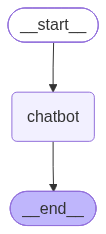

In [6]:
graph = StateGraph(State)


graph.add_node("chatbot", chatbot)

graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)


graph_complied = graph.compile()
graph_complied


In [7]:
#isinstance(graph_complied, Runnable), isinstance(graph, Runnable)

Test the Graph

In [8]:
graph_complied.invoke(state)


--------------> Entering Chatbot:
================================== Ai Message ==================================


<think>
Here's a thinking process:

1.  **Understand User Query**: The user asks "Can You tell me about blackhole ?" - a straightforward request for information about black holes.

2.  **Identify Key Topics to Cover**:
   - Definition/What is a black hole?
   - How are they formed?
   - Key features/structure (event horizon, singularity, accretion disk, etc.)
   - Types of black holes (stellar, supermassive, intermediate, primordial)
   - How we detect/observe them
   - Interesting facts/phenomena (time dilation, spaghettification, Hawking radiation)
   - Current research/open questions
   - Keep it accessible but scientifically accurate

3.  **Structure the Response**:
   - Introduction/Definition
   - Formation
   - Structure/Key Features
   - Types
   - Detection/Observation
   - Fascinating Phenomena
   - Current Research & Mysteries
   - Conclusion
   - Keep it con

{'messages': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Understand User Query**: The user asks "Can You tell me about blackhole ?" - a straightforward request for information about black holes.\n\n2.  **Identify Key Topics to Cover**:\n   - Definition/What is a black hole?\n   - How are they formed?\n   - Key features/structure (event horizon, singularity, accretion disk, etc.)\n   - Types of black holes (stellar, supermassive, intermediate, primordial)\n   - How we detect/observe them\n   - Interesting facts/phenomena (time dilation, spaghettification, Hawking radiation)\n   - Current research/open questions\n   - Keep it accessible but scientifically accurate\n\n3.  **Structure the Response**:\n   - Introduction/Definition\n   - Formation\n   - Structure/Key Features\n   - Types\n   - Detection/Observation\n   - Fascinating Phenomena\n   - Current Research & Mysteries\n   - Conclusion\n   - Keep it concise, well-organized, and engaging.\n\n4.  **Draft - Secti

Graph 2
====================

In [27]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

In [28]:
def ask(state:State)-> State:
    print("\n--------------> Entering Ask Question:")
    print("What is the Question?")
    return State(messages = [HumanMessage(input())])

#ask(State(messages=[]))

In [29]:
chat = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    #max_output_tokens=1000,
    temperature=0,
    seed=42
)

In [30]:
def chatbot(state:State)-> State:
    print("\n--------------> Entering Chatbot:")
    response = chat.invoke(state['messages'])
    response.pretty_print()
    return State(messages = [response])

In [31]:
def ask_another(state:State)-> State:
    print("\n--------------> Entering ask another:")
    print("You want to ask another Question (Yes/No)")
    return State(messages = [HumanMessage(input())])

#ask_another(State(messages=[]))

In [32]:
def routing(state:State)-> Literal["ask", "__end__"]:
    if state["messages"][0].content.lower() == "yes":
        return "ask"
    else:
        return "__end__"

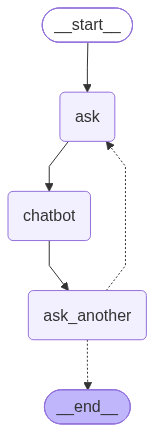

In [33]:
graph = StateGraph(State)

graph.add_node('ask', ask)
graph.add_node('chatbot', chatbot)
graph.add_node('ask_another', ask_another)

graph.add_edge(START, "ask")
graph.add_edge("ask", "chatbot")
graph.add_edge("chatbot", "ask_another")
graph.add_conditional_edges(source='ask_another', path = routing)

graph_complied = graph.compile()

graph_complied

In [34]:
graph_complied.invoke(State(messages=[]))


--------------> Entering Ask Question:
What is the Question?

--------------> Entering Chatbot:


c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


================================== Ai Message ==================================

[{'type': 'text', 'text': 'The Prime Minister of India is **Narendra Modi**. He has been serving in this position since May 2014.', 'extras': {'signature': 'EuQECuEEARFNMg+c8uzs+jTjJpXXEwhTOTbI41OPwdR54yNg3HfCarExJjCnLNgorfiC0FG4euAwCVuexVUzK2jIG8aDQNX+vpIbf4lLd7VeFMvwLFex8ZE/CD25b9PvCe+OlnVFCaSRE/JaBY+h1eTjaReF3APb6UyV7Dy5pE5+h9vnAvMtBZG5jp/YgJCiBT0xkFxQdMz9grjS8egfszYLdp3wUQH9/C+KEGmE2CKKrpNKAJ0uNzvpG90MArlEWmTYfk+xomfBdkrVu5yQ5Em2/G3vhpYh68Lw17hHopWqZE8mN94fUk1QXO8k6dztf8B94QcnFpi4CW7EseMs8BSHXZ+ZKZkdIlPT4F3WMJNMHJrs77d3oPSNKLu+8Wbcz8uVQyaws7cYqin9THaoMAF+1nh5Z3Eva/ZDFR3WP0bsCKTyyFaawf2+/KMv4bvgXIJMFDFOHzfnIwbSH8byMOHib3SvzfnrqOoHvwSYQ/BQYGxTMfj2QT1mK/q7bn2LlR7CCID0sFCKm1kTaCqx2Hl7AdQd+sEZxZ3LbpG0RLJLJ2qgrTCB4GSLeDBcHOuyNt3r5hkuC+nhR/55UsS2IXVe2Jdq3vukUnq2T7ubdeL9Lo9a7KVNx/bpBiaWeVQ0Dhv+TkIY5P69l+VEuWkdT3zNTReo9sqVxyz/kKWU0zGKQy8tUxN36DysTMbAqMBLuauUtvD7YhdkCqR0XYmmr8V0vyjG0cGJhZCI1zhg+VOHBxenMqDfwMLv+

c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


================================== Ai Message ==================================

[{'type': 'text', 'text': "It looks like you didn't mention who you are asking about. \n\nCould you please specify the person's name?", 'extras': {'signature': 'ErEFCq4FARFNMg8UO/nwfVgc2FgCEYyTkT9kdD3qe6rkHkkr4Q1++ti7fwATIKbip3g5dDbhddrSmPOEEhePeigxRtYyjNkHpDZOJdH9ljnzbEBVmeZZLogZNevNOKREMRx6yWpP9OhQRrULnbCPR61FeBL3+54OJalISk7GCE6MnSqh3k2kLN4yJc4Ojc2nFFfC921laPS7RoC0gXVipNoclrqQXywm/stvfOd4/wqiEjRRGwuMGQ7FEvwSfczOtvlTBzGv1NIByH2awrRQtEV77iUs28nWDR4JGYwbdNntUrZ2Z9pAO17YuCPkGK5pEc0W+KnYJAR3TOEmGUFp8WiqvtWHsMujac7yAfpiGVbgh3fCaaXyOlYX8MJym+tHTqTZ1PGt4qyFhcYs7PQUF6c8CyBeANVLqFLGdYi2a3Jdx8+ltlyZaNPzRi2nipQQiYYnRwBKzLgqvxAnbAUYokpR4kH/lZ/NdITBLFtIkRpvSfUmG95GRKH1eyQcYTCnTqwA/PxFJhVPFNvBpi0e7487WK39D+mb+/381Lak1fVBoaRRVpJiY8t6PCp378zbap4fooGS3vCLZATau+jvCjIo6NVmi0HbEJqNaj+LtpEuuPjOKG5oq8V1Z927m6eZ9dRNT5d1gzZN0p+SoscHmHWH0urV9drK1Js9AnWNubmXlAYb7cGwY6ugYIgy+eyezjXxBVfnb8NOjT2mgcQZ+w6Vw4OEiN8Q61QcM99PULTcUSuKWaL69

{'messages': [HumanMessage(content='no', additional_kwargs={}, response_metadata={})]}